In [10]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Load a subset of the 20 Newsgroups dataset
# newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
# documents = newsgroups.data

# documents = [
#     "The economy is working better than ever", # economy
#     "The president is speaking on the economy", # economy
#     "The sports team won the championship", # sports
#     "The new movie was a hit at the box office", # movie
#     "The local team lost the game last night", # sports
#     "The government is working on new policies", # economy
#     "The film received great reviews from critics", # movie
#     "The match was intense and thrilling", # sports
#     "The administration is focusing on economic growth", # economy
#     "The actor won an award for his performance", # movie
# ]

# The following works too

documents = [
    # economy
    "The government introduced a new policy aimed at improving the economy by creating more jobs.",
    "Market analysts believe that better fiscal strategies will enhance economic growth and employment rates.",
    "To improve the job market, the government is focusing on policies that stimulate economic development.",
    "Economic experts suggest that better governance and policy reforms are essential for a thriving market.",
    "The government's commitment to job creation reflects its strategy to improve the overall economy and market stability.",

    # sports
    "The sports team trained rigorously to prepare for the championship match.",
    "Despite their best efforts, the team lost the game against the reigning champions.",
    "After a series of intense matches, they finally won and were crowned champions.",
    "The underdog team surprised everyone when they won the crucial game.",
    "Even though they lost the match, the team's performance was commendable in the sports community.",

     # movie
    "The action-packed movie became a box office hit, earning rave reviews from critics and audiences alike.",
    "The lead actor delivered a stellar performance in the action film, which was nominated for several Oscars.",
    "Despite mixed reviews, the movie's thrilling action sequences propelled it to box office success.",
    "The actor's portrayal in the movie garnered critical acclaim, leading to an Oscar win and a significant box office hit.",
    "The action movie received outstanding reviews and became a surprise hit during the Oscars season.",
]



In [11]:

# Convert the text documents to a document-term matrix
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
doc_term_matrix = vectorizer.fit_transform(documents)

# Define the number of topics
num_topics = 3

# Create and fit the LDA model
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_model.fit(doc_term_matrix)

import numpy as np

def display_topics(model, feature_names, num_top_words):
    for topic_idx, topic in enumerate(model.components_):
        # Normalize to obtain probabilities
        topic_prob = topic / topic.sum()
        top_indices = topic.argsort()[:-num_top_words - 1:-1]
        top_words = [(feature_names[i], topic_prob[i]) for i in top_indices]
        print(f"Topic {topic_idx + 1}:")
        for word, weight in top_words:
            print(f"  {word:<15} {weight:.4f}")
        print()

# Display the top words for each topic
num_top_words = 10
feature_names = vectorizer.get_feature_names_out()
display_topics(lda_model, feature_names, num_top_words)


Topic 1:
  market          0.1529
  government      0.1176
  economic        0.1176
  improve         0.0823
  job             0.0823
  economy         0.0823
  better          0.0823
  policy          0.0823
  won             0.0118
  performance     0.0118

Topic 2:
  movie           0.1296
  action          0.1295
  reviews         0.0997
  box             0.0997
  office          0.0997
  hit             0.0997
  actor           0.0694
  oscars          0.0694
  despite         0.0398
  performance     0.0136

Topic 3:
  team            0.1590
  lost            0.0856
  sports          0.0856
  match           0.0856
  game            0.0856
  champions       0.0856
  won             0.0856
  performance     0.0811
  despite         0.0490
  oscars          0.0127



**Analysis**

<ipython-input-15-bcd0b2ab261c>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weights, y=top_words, palette='viridis', ax=ax)


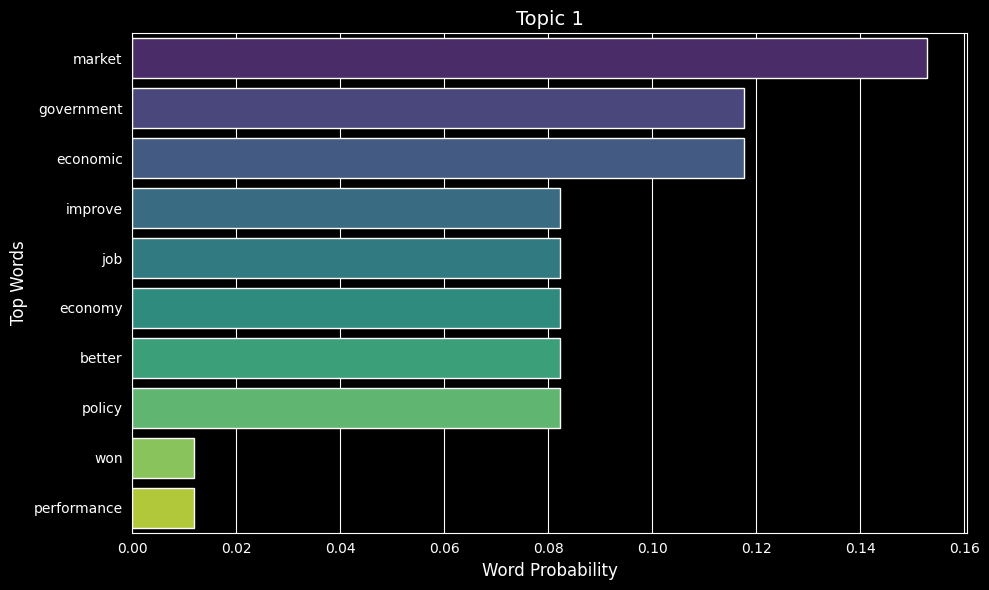

--------------------------------------------------------------------------------


<ipython-input-15-bcd0b2ab261c>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weights, y=top_words, palette='viridis', ax=ax)


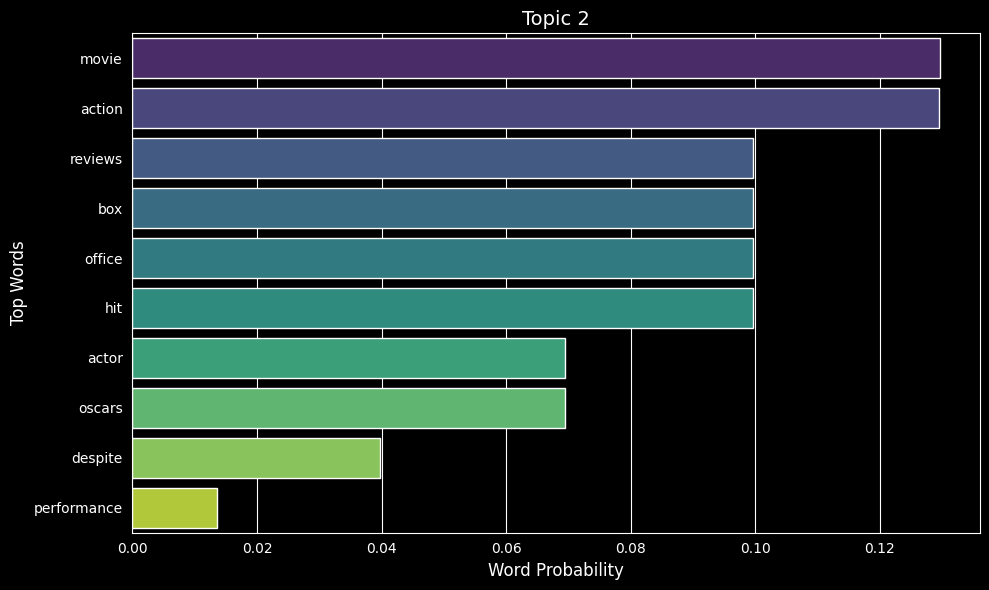

--------------------------------------------------------------------------------


<ipython-input-15-bcd0b2ab261c>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weights, y=top_words, palette='viridis', ax=ax)


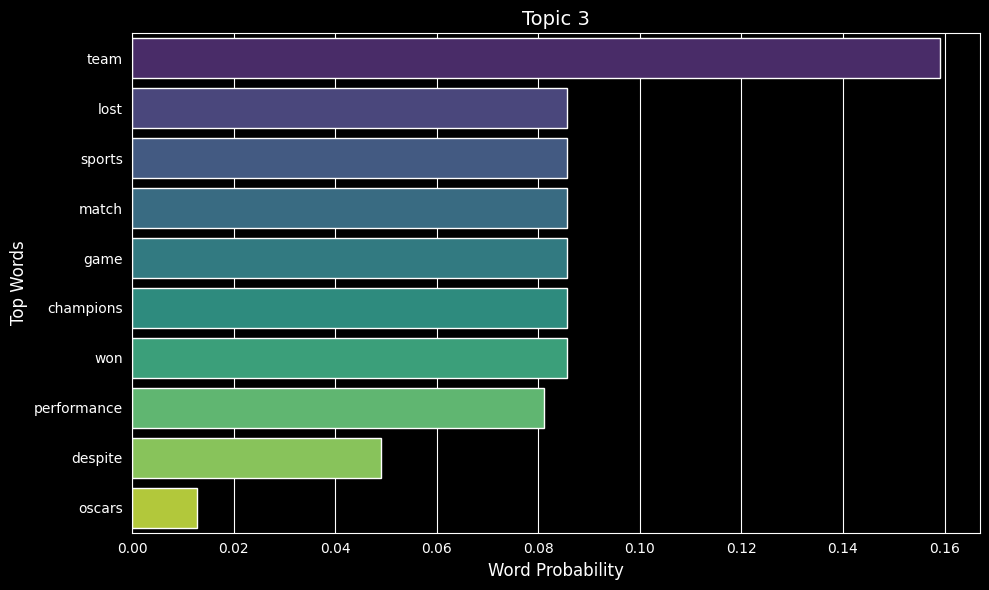

--------------------------------------------------------------------------------


In [15]:
# lets plot barchart

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_lda_topics_bar_chart(lda_model, feature_names, num_top_words=10):
    # Set the overall style to dark background
    plt.style.use('dark_background')
    sns.set_style("darkgrid")

    for topic_idx, topic in enumerate(lda_model.components_):
        # Normalize to obtain probabilities
        topic_prob = topic / topic.sum()
        top_indices = topic.argsort()[:-num_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        top_weights = topic_prob[top_indices]

        # Create the plot
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor('black')  # Set figure background to black
        ax.set_facecolor('black')         # Set axes background to black

        # Plot the horizontal bar chart
        sns.barplot(x=top_weights, y=top_words, palette='viridis', ax=ax)

        # Customize the plot
        ax.set_title(f"Topic {topic_idx + 1}", fontsize=14, color='white')
        ax.set_xlabel("Word Probability", fontsize=12, color='white')
        ax.set_ylabel("Top Words", fontsize=12, color='white')
        ax.tick_params(colors='white')  # Set tick color to white

        # Display the plot
        plt.tight_layout()
        plt.show()

        # Separator between figures
        print("-" * 80)

# Number of top words to display in the word cloud
num_top_words = 10

# Feature names from the CountVectorizer
feature_names = vectorizer.get_feature_names_out()

plot_lda_topics_bar_chart(lda_model, feature_names, num_top_words)

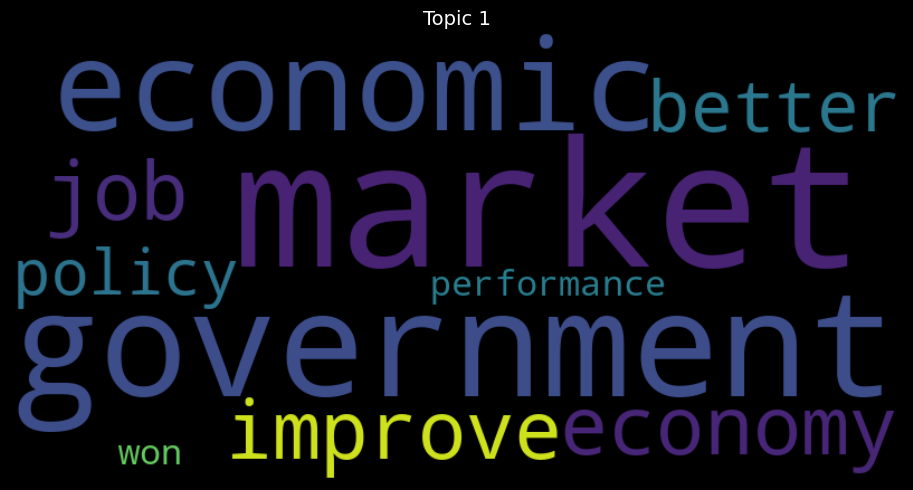

--------------------------------------------------------------------------------


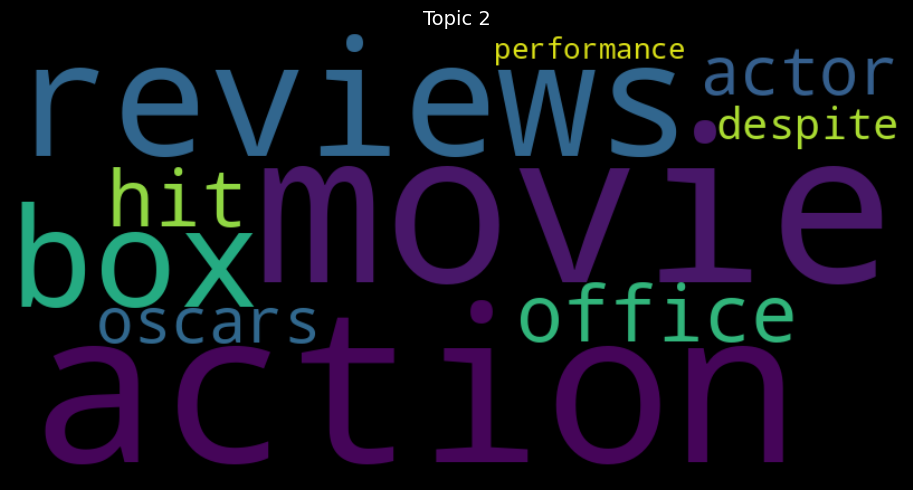

--------------------------------------------------------------------------------


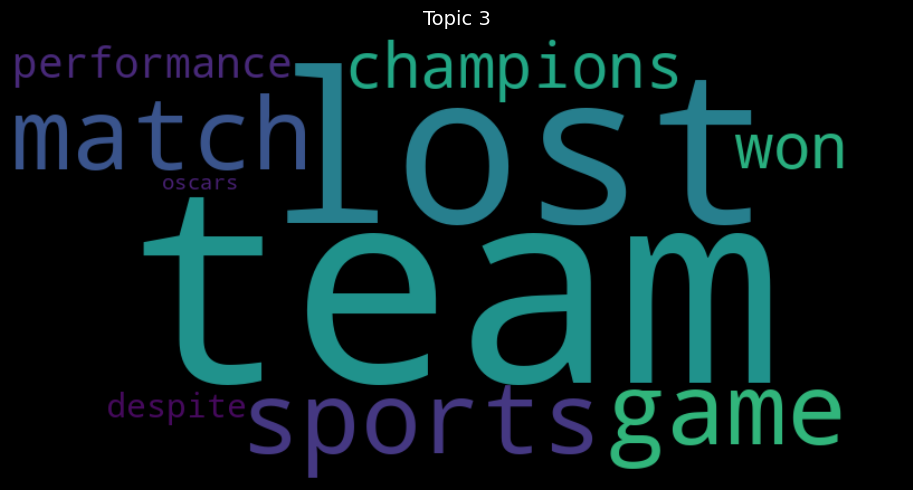

--------------------------------------------------------------------------------


In [17]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def plot_lda_wordclouds(lda_model, feature_names, num_top_words=10):
    # Set the overall style to dark background
    plt.style.use('dark_background')

    for topic_idx, topic in enumerate(lda_model.components_):
        # Normalize to obtain probabilities
        topic_prob = topic / topic.sum()
        top_indices = topic.argsort()[:-num_top_words - 1:-1]
        top_words = {feature_names[i]: topic_prob[i] for i in top_indices}

        # Generate word cloud with black background
        wordcloud = WordCloud(width=800, height=400, background_color='black')
        wordcloud.generate_from_frequencies(top_words)

        # Create the plot
        fig, ax = plt.subplots(figsize=(10, 5))
        fig.patch.set_facecolor('black')  # Set figure background to black
        ax.set_facecolor('black')         # Set axes background to black

        # Plot the word cloud
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f"Topic {topic_idx + 1}", fontsize=14, color='white')

        # Display the plot
        plt.tight_layout()
        plt.show()

        # Separator between figures
        print("-" * 80)


# Number of top words to display in the word cloud
num_top_words = 10

# Feature names from the CountVectorizer
feature_names = vectorizer.get_feature_names_out()

# Plot word clouds for each topic
plot_lda_wordclouds(lda_model, feature_names, num_top_words)
